In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("/content/titanic.csv")

In [3]:
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


In [4]:
df['number'].unique()

array(['5', '3', '6', 'A', '2', '1', '4'], dtype=object)

Text(0.5, 1.0, 'Passanger Travelling with')

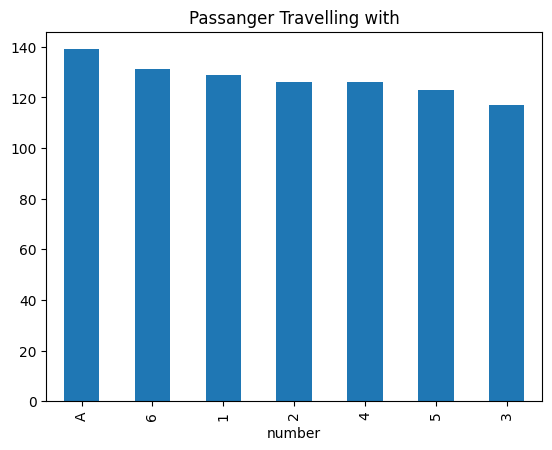

In [6]:
fig = df['number'].value_counts().plot.bar()
fig.set_title("Passanger Travelling with")

In [9]:
#since the number column has both alpha and numeric values
#we will be extracting the numeric values in one column and the categorical values in the other fcolumn
#EXTRACTING THE NUMERIC VALUES
df['numeric_values'] = pd.to_numeric(df['number'] , errors = 'coerce')

In [10]:
df['numeric_categorical'] = np.where(df['numeric_values'].isnull(),df['number'],np.nan)

In [11]:
df.head()

,Cabin,Ticket,number,Survived,numeric_values,numeric_categorical
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


In [12]:
df['cabin_num'] = df['Cabin'].str.extract('(\d+)')  #('(\d+)') - this expression is used for extracting the numerical part
df['cabin_cat'] = df['Cabin'].str[0] #captures the 1st letter

df.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3089170357.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['cabin_num'] = df['Cabin'].str.extract('(\d+)')


,Cabin,Ticket,number,Survived,numeric_values,numeric_categorical,cabin_num,cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN


<Axes: xlabel='cabin_cat'>

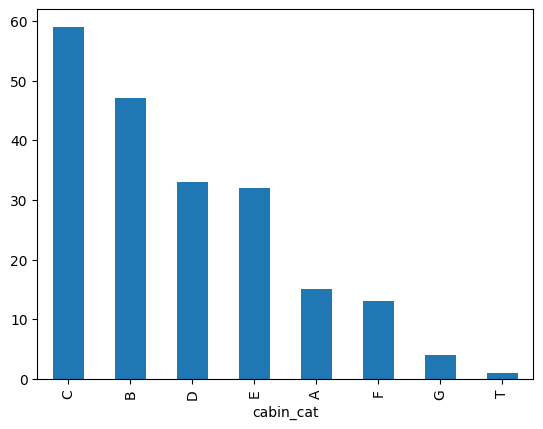

In [14]:
df['cabin_cat'].value_counts().plot(kind = 'bar')

In [16]:
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])
df['ticket_num'] = pd.to_numeric(df['ticket_num'],
                                 errors = 'coerce')
df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])
df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit() , np.nan , df['ticket_cat'])

In [17]:
df.head()

,Cabin,Ticket,number,Survived,numeric_values,numeric_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,NaN
